In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Wed May 13 09:48:48 2026

@author: kmc249
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
from astropy.time import Time
import matplotlib.dates as mdates
import glob
from collections import OrderedDict
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from astropy.timeseries import LombScargle

In [2]:
#read in all the dfs

data = {}

data['B SMARTS'] = {
    'df': pd.read_csv('/neta/xrb/AqlX-1/product/just_subtracted_shifted/AqlX-1_B_corrected_lc_4_27.csv')
}

data['V SMARTS'] = {
    'df': pd.read_csv('/neta/xrb/AqlX-1/product/just_subtracted_shifted/AqlX-1_V_corrected_lc_4_27.csv')
}

data['R SMARTS'] = {
    'df': pd.read_csv('/neta/xrb/AqlX-1/product/just_subtracted_shifted/AqlX-1_R_corrected_lc.csv')
}

data['I SMARTS'] = {
    'df': pd.read_csv('/neta/xrb/AqlX-1/product/just_subtracted_shifted/AqlX-1_I_corrected_lc_4_27.csv')
}

data['J SMARTS'] = {
    'df': pd.read_csv('/neta/xrb/AqlX-1/product/just_subtracted_shifted/AqlX-1_J_corrected_lc.csv')
}

data['H SMARTS'] = {
    'df': pd.read_csv('/neta/xrb/AqlX-1/product/just_subtracted_shifted/AqlX-1_H_corrected_lc.csv')
}

data['K SMARTS'] = {
    'df': pd.read_csv('/neta/xrb/AqlX-1/product/just_subtracted_shifted/AqlX-1_K_corrected_lc.csv')
}


for key in data:
    df = data[key]['df']
    if key=='J SMARTS':
        nameband='J'
    elif key=='K SMARTS':
        nameband='K'
    elif key=='H SMARTS':
        nameband='H'
    else:
        nameband='R'
    if key=='V SMARTS':
        df['mag_shifted']=df[f'{nameband}mag_shifted']
    else:
        df['mag_shifted']=df[f'{nameband}mag_corr']
    df['mag_corr_err']=df[f'e_{nameband}mag_corr']
    df['mag_err']=df[f'e_{nameband}mag']
    df['mag']=df[f'{nameband}mag']
    
    df['flag']=np.nan
    df['error_flag']=np.nan

#assume we've gotten rid of the bad guys already.

def read_corrected_txt(path):
    df = pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        names=[
            "MJD",
            "mag_corr",
            "mag_corr_err",
            "flag",
            "mag",
            "mag_err",
            "error_flag"
        ]
    )
    
    df["nice time"] = pd.to_datetime(Time(df["MJD"], format="mjd").to_datetime())
    return df

def read_lco(banzai_path, orac_path):
    banzai = read_corrected_txt(banzai_path)
    orac   = read_corrected_txt(orac_path)
    return pd.concat([banzai, orac], ignore_index=True)


for band in ['V','gp','R','rp','ip']:
    data[f'{band} LCO']={'df':pd.read_csv(f'/home/kmc249/Downloads/{band}_LCO_shifted.csv')}

data['V LCO']['df']['mag_shifted']=data['V LCO']['df']['mag_corr']
data['V LCO']['df']['alt_mag_shifted']=data['V LCO']['df']['alt_mag_corr']

#only get stuff in quiescence

#Outburst list
oldfull = pd.read_csv("/home/kmc249/Downloads/full_outbursts.csv")
full=pd.read_csv("/home/kmc249/Downloads/table.tsv", sep='\t', header=0, names=['OB','Start MJD', 'End MJD'])
mini = pd.read_csv("/home/kmc249/Downloads/mini_outbursts.csv")

#Mask out quiescence
count_mini = True

full_intervals = (
    list(zip(full["Start MJD"], full["End MJD"])) +
    list(zip(mini["Start MJD"], mini["End MJD"]))
)

if count_mini:
    intervals = full_intervals
else:
    intervals = list(zip(full["Start MJD"], full["End MJD"]))

#quiescent intervals
all_mjd = np.concatenate([
    data[key]["df"]["MJD"].values
    for key in data
])

data_start = np.min(all_mjd)
data_end   = np.max(all_mjd)

intervals = sorted(intervals, key=lambda x: x[0])

quiescent_intervals = []

quiescent_intervals.append(
    (data_start, intervals[0][0])
)

for i in range(len(intervals)-1):

    end_current = intervals[i][1]
    start_next  = intervals[i+1][0]

    if start_next > end_current:
        quiescent_intervals.append(
            (end_current, start_next)
        )

quiescent_intervals.append(
    (intervals[-1][1], data_end)
)
    

def get_quiescent(df, intervals):
    mask = np.ones(len(df), dtype=bool)
    
    for start, end in intervals:
        mask &= ~((df["MJD"] >= start) & (df["MJD"] <= end))
    
    return df[mask].copy()

for key in data:
    df = data[key]['df']
    data[key]['quiescence'] = get_quiescent(df, intervals)
    data[key]['global med q mag'] = data[key]['quiescence']['mag_shifted'].median()
    data[key]['global mean q mag'] = data[key]['quiescence']['mag_shifted'].mean()
    print(key, data[key]['global mean q mag'])
    
    

B SMARTS 20.52055567426903
V SMARTS 21.696923476705823
R SMARTS 20.463290369522014
I SMARTS 19.606184852359323
J SMARTS 18.210904592235686
H SMARTS 17.33171244352994
K SMARTS 16.220001939808057
V LCO 21.70324703887337
gp LCO 21.717725220690845
R LCO 20.467086111191808
rp LCO 20.481902089024775
ip LCO 19.631276116397405


In [3]:
#Resaving files because I suck
for key in data:
    savetable=data[key]['df']
    band=key.split(' ')[0]
    header = f"# MJD corrected {band} MAG corrected uncertainty upperlimitflag {band} MAG uncertainty error_flag"
    if not 'LCO' in key:
        tosave=savetable[['MJD', 'mag_shifted', 'mag_corr_err', 'flag', 'mag', 'mag_err', 'error_flag']]
        with open(f'/neta/xrb/AqlX-1/product/full_bands_subtracted/{band}_SMARTS_corrected.txt', "w") as file:
            file.write(header + "\n")
            
            tosave.to_csv(
                file,
                sep=" ",
                index=False,
                header=False,
            )
        continue

    tosave=savetable[['MJD', 'mag_shifted', 'mag_corr_err', 'flag', 'mag', 'mag_err', 'error_flag']]
    with open(f'/neta/xrb/AqlX-1/product/full_bands_subtracted/{band}_usable_full_corrected.txt', "w") as file:
        file.write(header + "\n")
        
        tosave.to_csv(
            file,
            sep=" ",
            index=False,
            header=False,
        )

In [4]:
#epochs, I think based on all times
def assign_quiescent_epochs(df, quiescent_intervals):

    df = df.copy()

    df["epoch"] = -1

    for i, (start, end) in enumerate(quiescent_intervals):

        mask = (
            (df["MJD"] >= start) &
            (df["MJD"] <= end)
        )

        df.loc[mask, "epoch"] = i

    return df

def compute_epoch_medians(df):
    return df.groupby("epoch")["mag_shifted"].median()

def classify_epochs(epoch_medians, global_med):
    local = epoch_medians.values

    state = np.where(
        np.isnan(local),
        "none",
        np.where(local < global_med, "active", "passive")
    )

    return pd.DataFrame({
        "epoch": epoch_medians.index,
        "local_median": local,
        "state": state,
        "difference": local-global_med
    })

In [5]:
#null hypothesis is that for a given epoch (of a given size), its local median is explainable by random choice
#hypothesis other than that is that the local median is statistically significant

def get_pvalue(key,a=0.05, n_iter=10000):
    #for a given band, let's randomly sample the same size as its epochs and
    #get median values. Run a monte-carlo P test for the null hypothesis and 
    #return an array of p values for the epochs.
    df=data[key]['quiescence']

    grouped = df.groupby("epoch")

    all_vals = df["mag_shifted"].values
    results = []
    #For each differently sized epoch:
    for epoch, group in grouped:
        n = len(group)
        #sample a bunch and find the medians of each sample
        fake_medians=[]
        for _ in range(n_iter):
            #simulated data
            fake = np.random.choice(all_vals, size=n)
            fake_med = np.median(fake)
            fake_medians.append(fake_med)
        #now for this epoch, we have a distribution of simulated medians
        fake_medians=np.array(fake_medians)
        #and the observed median
        obs_med = np.median(group["mag_shifted"])
        
        #monte carlo p-value?
        center = np.median(all_vals) 

        p_value = (np.sum(np.abs(fake_medians - center) >= abs(obs_med - center)) + 1) / (n_iter + 1)
        if p_value<a:
            sig='significant'
        else:
            sig='not significant'
        results.append({
            "epoch": epoch,
            "p_value": p_value,
            "n": n,
            "obs_median": obs_med,
            "sig": sig
        })
        '''
        try:
            plt.figure(figsize=(8,4))
            plt.hist(fake_medians, bins=50)
            plt.title(f'{key}, epoch {epoch}')
            #plt.savefig(f'/home/kmc249/Downloads/simulated_histograms/f{key}_{epoch}.png')
            plt.show()
        except:
            continue
        '''

    return pd.DataFrame(results)

In [6]:
#find the epochs and compute some medians
for key in data:

    df = data[key]["quiescence"]
    # 1. assign epochs
    df = assign_quiescent_epochs(
        df,
        quiescent_intervals
    )

    data[key]["quiescence"] = df

    # 2. local epoch medians
    epoch_medians = compute_epoch_medians(df)

    # 3. classification
    epoch_table = classify_epochs(epoch_medians, data[key]['global med q mag'])

    data[key]['epoch_table'] = epoch_table
    df = df.merge(data[key]['epoch_table'][["epoch", "state"]], on="epoch", how="left")


#check to see if epochs agree
epoch_states = []
for key in data:
    data[key]["epoch_pvalues"] = get_pvalue(key, n_iter=10000)

    data[key]['epoch_table'] = data[key]['epoch_table'].merge(
        data[key]["epoch_pvalues"][["epoch", "p_value", "sig"]],
        on="epoch",
        how="left"
    )

    tmp = data[key]["epoch_table"].copy()
    tmp["band"] = key
    epoch_states.append(tmp)

epoch_states = pd.concat(epoch_states, ignore_index=True)
comparison = epoch_states.pivot_table(
    index="epoch",
    columns="band",
    values="state",
    aggfunc="first"
)
def row_agreement(row):
    vals = row.dropna().values

    # remove "none"
    vals = vals[vals != "none"]

    if len(vals) == 0:
        return "no_data"

    if np.all(vals == vals[0]):
        return "agree"

    return "disagree"

comparison["agreement"] = comparison.apply(row_agreement, axis=1)
def agreement_fraction(row):
    vals = [v for v in row.values if v in ["active", "passive"]]

    if len(vals) == 0:
        return np.nan

    most_common = max(set(vals), key=vals.count)
    return vals.count(most_common) / len(vals)

comparison["disagreement_score"] = comparison.apply(agreement_fraction, axis=1)

for key in data:
    df = data[key]["quiescence"].copy()

    df = df.merge(
        data[key]["epoch_table"][["epoch", "state", "p_value", "sig"]],
        on="epoch",
        how="left"
    )

    df = df.merge(
        comparison[["agreement"]],
        left_on="epoch",
        right_index=True,
        how="left"
    )

    data[key]["plot_df"] = df

In [7]:
#null hypothesis is that for a given epoch (of a given size), its local median is explainable by random choice
#hypothesis other than that is that the local median is statistically significant

def ks_test(key,a=0.05, n_iter=10000):
    #for a given band, let's randomly sample the same size as its epochs and
    #get median values. Run a monte-carlo P test for the null hypothesis and 
    #return an array of p values for the epochs.
    df=data[key]['plot_df']

    grouped = df.groupby("epoch")

    all_vals = df["mag_shifted"].values
    percentiles = []
    states=[]
    #For each differently sized epoch:
    for epoch, group in grouped:

        print(group.columns)
        n = len(group)
        #sample a bunch and find the medians of each sample
        fake_medians=[]
        for _ in range(n_iter):
            #simulated data
            fake = np.random.choice(all_vals, size=n)
            fake_med = np.median(fake)
            fake_medians.append(fake_med)
        #now for this epoch, we have a distribution of simulated medians
        fake_medians=np.array(fake_medians)
        #and the observed median
        obs_med = np.median(group["mag_shifted"])
        
        #how many simulated values are smaller?
        rank = np.sum(fake_medians < obs_med)  
        percentile = rank / len(fake_medians)
        
        percentiles.append(percentile)
        state = group["state"].mode().iloc[0] if "state" in group else "none"
        states.append(state)
    
    percentiles=np.array(percentiles)
    states=np.array(states)
    
    # split by state
    active = percentiles[states == "active"]
    passive = percentiles[states == "passive"]
    
    # x-grid
    x = np.linspace(0, 1, 200)
    
    # empirical CDFs
    y_active = np.array([np.mean(active <= xi) for xi in x])
    y_passive = np.array([np.mean(passive <= xi) for xi in x])
    y = np.array([np.mean(percentiles <= xi) for xi in x])
    
   
    """
    # plot
    plt.figure(figsize=(6,5))
    
    plt.plot(x, y_active, color="blue", label="active")
    plt.plot(x, y_passive, color="orange", label="passive")
    plt.plot(x, y, label="All states", color='red')
    
    # ideal uniform line
    plt.plot([0, 1], [0, 1], '--', color='black', label="x=y")
    plt.plot([0, 0.5], [0, 1], '--', color='blue', label="active expected")
    plt.plot([0.5, 1.0], [0.0, 1.0], '--', color="orange", label="passive expected")
    plt.title(key)
    plt.xlabel("x (percentile threshold)")
    plt.ylabel("Fraction of percentiles ≤ x")
    plt.legend()
    #plt.savefig(f'/home/kmc249/Downloads/cdf_{key}.png')
    plt.show()
    """

In [8]:
for key in data:
    ks_test(key,a=0.05, n_iter=10000)

Index(['nice time', 'MJD', 'Rmag_corr', 'e_Rmag_corr', 'Rmag', 'e_Rmag',
       'filename', 'mag_shifted', 'mag_corr_err', 'mag_err', 'mag', 'flag',
       'error_flag', 'epoch', 'state', 'p_value', 'sig', 'agreement'],
      dtype='object')
Index(['nice time', 'MJD', 'Rmag_corr', 'e_Rmag_corr', 'Rmag', 'e_Rmag',
       'filename', 'mag_shifted', 'mag_corr_err', 'mag_err', 'mag', 'flag',
       'error_flag', 'epoch', 'state', 'p_value', 'sig', 'agreement'],
      dtype='object')
Index(['nice time', 'MJD', 'Rmag_corr', 'e_Rmag_corr', 'Rmag', 'e_Rmag',
       'filename', 'mag_shifted', 'mag_corr_err', 'mag_err', 'mag', 'flag',
       'error_flag', 'epoch', 'state', 'p_value', 'sig', 'agreement'],
      dtype='object')
Index(['Unnamed: 0', 'nice time', 'MJD', 'Rmag_corr', 'e_Rmag_corr', 'Rmag',
       'e_Rmag', 'filename', 'Rmag_shifted', 'mag_shifted', 'mag_corr_err',
       'mag_err', 'mag', 'flag', 'error_flag', 'epoch', 'state', 'p_value',
       'sig', 'agreement'],
      dtype='obje

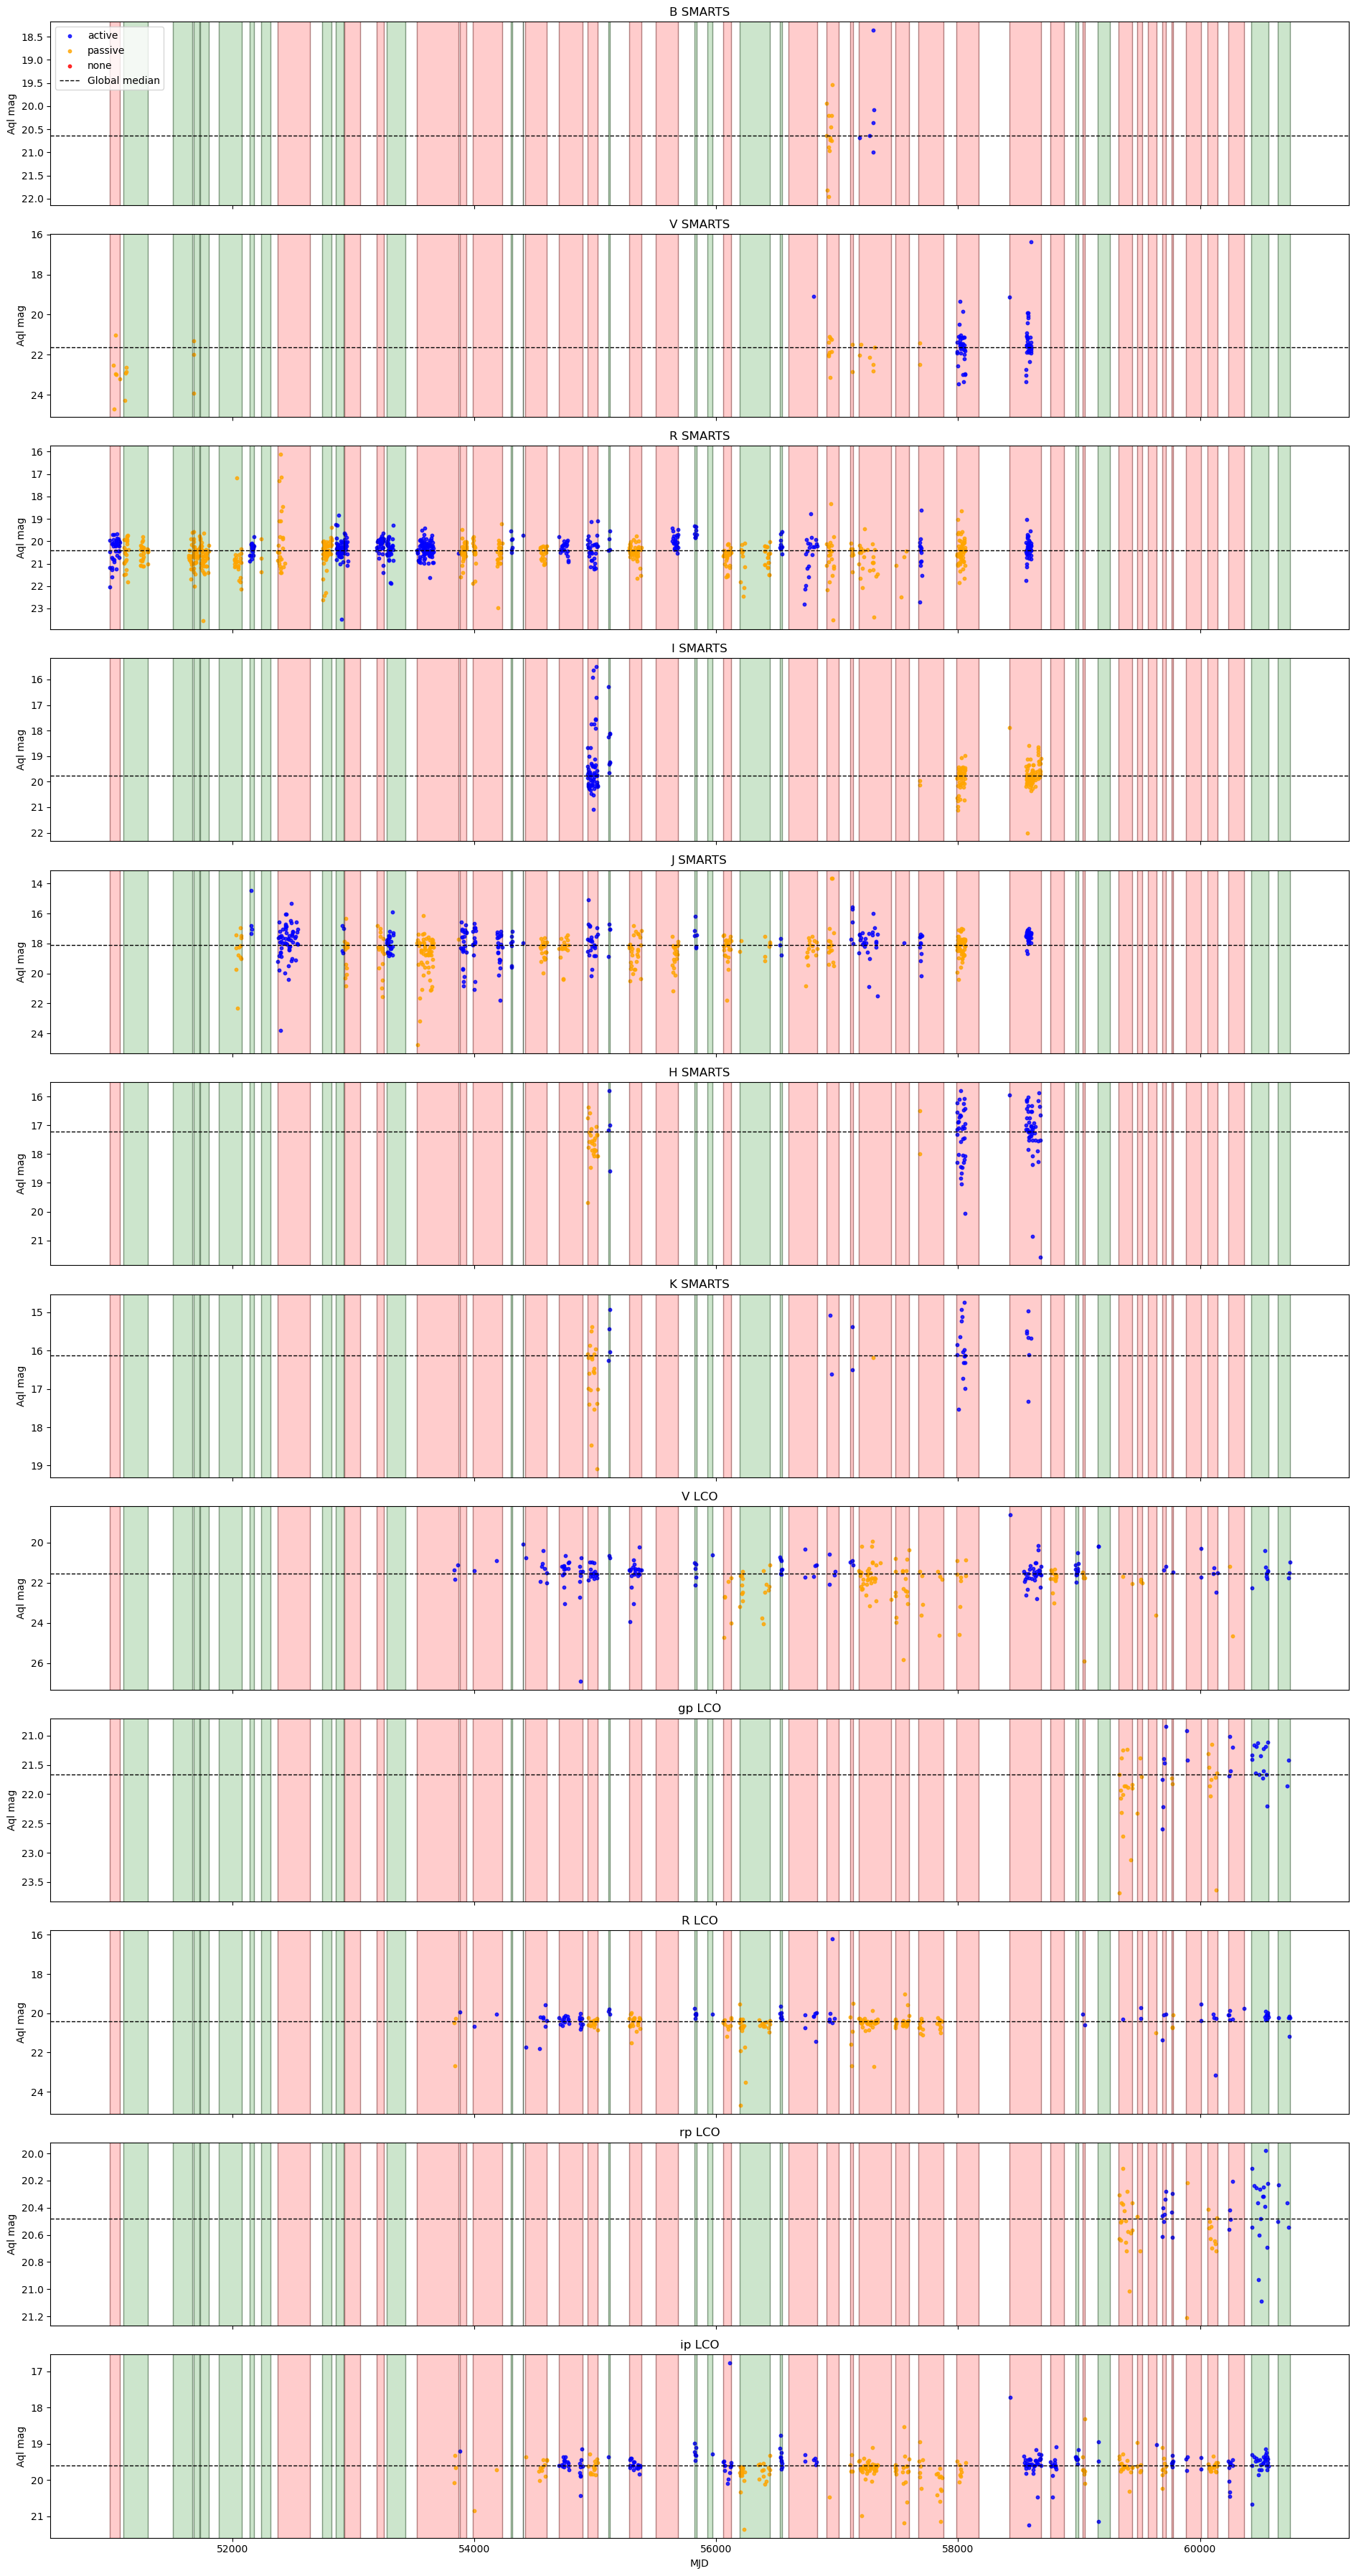

frac agrees
0.40384615384615385
total epochs: 52


In [9]:
#plotting business
state_colors = {
    "active": "blue",
    "passive": "orange",
    "none": "red"
}

fig, axes = plt.subplots(len(data), 1, figsize=(19, 3 * len(data)), sharex=True)

if len(data) == 1:
    axes = [axes]

for ax, (key, item) in zip(axes, data.items()):

    df = item["plot_df"]
    
    # ---- shaded epoch regions ----
    for i, (start, end) in enumerate(quiescent_intervals):

        epoch_id = i

        match = comparison.loc[epoch_id, "agreement"] if epoch_id in comparison.index else "no_data"

        if match == "agree":
            color = "green"
        elif match == "disagree":
            color = "red"
        else:
            color = "gray"

        ax.axvspan(start, end, color=color, alpha=0.2)

    # ---- scatter plot colored by state ----
    for state, color in state_colors.items():
        sub = df[df["state"] == state]
        ax.scatter(sub["MJD"], sub["mag_shifted"],
                   s=10, color=color, label=state, alpha=0.8)

    # ---- vertical epoch boundaries ----
    for start, end in quiescent_intervals:
        ax.axvline(start, color="k", alpha=0.3, linewidth=1)
        ax.axvline(end,   color="k", alpha=0.3, linewidth=1)


    ax.set_title(key)
    ax.set_ylabel("Aql mag")
    ax.invert_yaxis()
    
    ax.axhline(item['global med q mag'], linewidth=1, color='k', linestyle='--',label='Global median')

axes[-1].set_xlabel("MJD")

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend()

plt.tight_layout()
plt.show()
print('frac agrees')
print(comparison['agreement'].value_counts()['agree']/len(comparison))
print('total epochs:', len(comparison))

In [10]:
'''
#histograms
for key in data:
    df = data[key]["epoch_table"].copy()
    groups=df.groupby('state')
    x_min = df["difference"].min()
    x_max = df["difference"].max()
    bins = np.linspace(x_min, x_max, 61)
    plt.figure(figsize=(8,4))
    for state, group in df.groupby("state"):
        std=np.nanstd(group["difference"])
        med=group['difference'].median()
        if state=='none':
            continue
        if state=='active':
            c='blue'
            plt.axvline(-std, linestyle='--', color=c, label='std')
            plt.axvline(med, linestyle=':', color=c, label='median of active diff')
        elif state=='passive':
            c='orange'
            plt.axvline(std, linestyle='--', color=c, label='std')
            plt.axvline(med, linestyle=':', color=c, label='median of passive diff')
        plt.hist(
            group["difference"],
            bins=bins,
            alpha=0.5,
            label=state,
            density=True,
            color=c
        )
        
    plt.axvline(0, linestyle='-', color='k')

    plt.xlabel("magnitude difference")
    plt.gca().invert_xaxis()
    plt.ylabel("count")
    plt.title(f"{key}")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
'''

'\n#histograms\nfor key in data:\n    df = data[key]["epoch_table"].copy()\n    groups=df.groupby(\'state\')\n    x_min = df["difference"].min()\n    x_max = df["difference"].max()\n    bins = np.linspace(x_min, x_max, 61)\n    plt.figure(figsize=(8,4))\n    for state, group in df.groupby("state"):\n        std=np.nanstd(group["difference"])\n        med=group[\'difference\'].median()\n        if state==\'none\':\n            continue\n        if state==\'active\':\n            c=\'blue\'\n            plt.axvline(-std, linestyle=\'--\', color=c, label=\'std\')\n            plt.axvline(med, linestyle=\':\', color=c, label=\'median of active diff\')\n        elif state==\'passive\':\n            c=\'orange\'\n            plt.axvline(std, linestyle=\'--\', color=c, label=\'std\')\n            plt.axvline(med, linestyle=\':\', color=c, label=\'median of passive diff\')\n        plt.hist(\n            group["difference"],\n            bins=bins,\n            alpha=0.5,\n            label=st

Index(['nice time', 'MJD', 'Rmag_corr', 'e_Rmag_corr', 'Rmag', 'e_Rmag',
       'filename', 'mag_shifted', 'mag_corr_err', 'mag_err', 'mag', 'flag',
       'error_flag', 'epoch', 'state', 'p_value', 'sig', 'agreement'],
      dtype='object')
Index(['Unnamed: 0', 'nice time', 'MJD', 'Rmag_corr', 'e_Rmag_corr', 'Rmag',
       'e_Rmag', 'filename', 'Rmag_shifted', 'mag_shifted', 'mag_corr_err',
       'mag_err', 'mag', 'flag', 'error_flag', 'epoch', 'state', 'p_value',
       'sig', 'agreement'],
      dtype='object')
Index(['Unnamed: 0', 'nice time', 'MJD', 'Rmag_corr', 'e_Rmag_corr', 'Rmag',
       'e_Rmag', 'filename', 'Rmag Divided Version', 'mag_shifted',
       'mag_corr_err', 'mag_err', 'mag', 'flag', 'error_flag', 'epoch',
       'state', 'p_value', 'sig', 'agreement'],
      dtype='object')
Index(['Unnamed: 0', 'nice time', 'MJD', 'Rmag_corr', 'e_Rmag_corr', 'Rmag',
       'e_Rmag', 'filename', 'mag_shifted', 'mag_corr_err', 'mag_err', 'mag',
       'flag', 'error_flag', 'epoch',

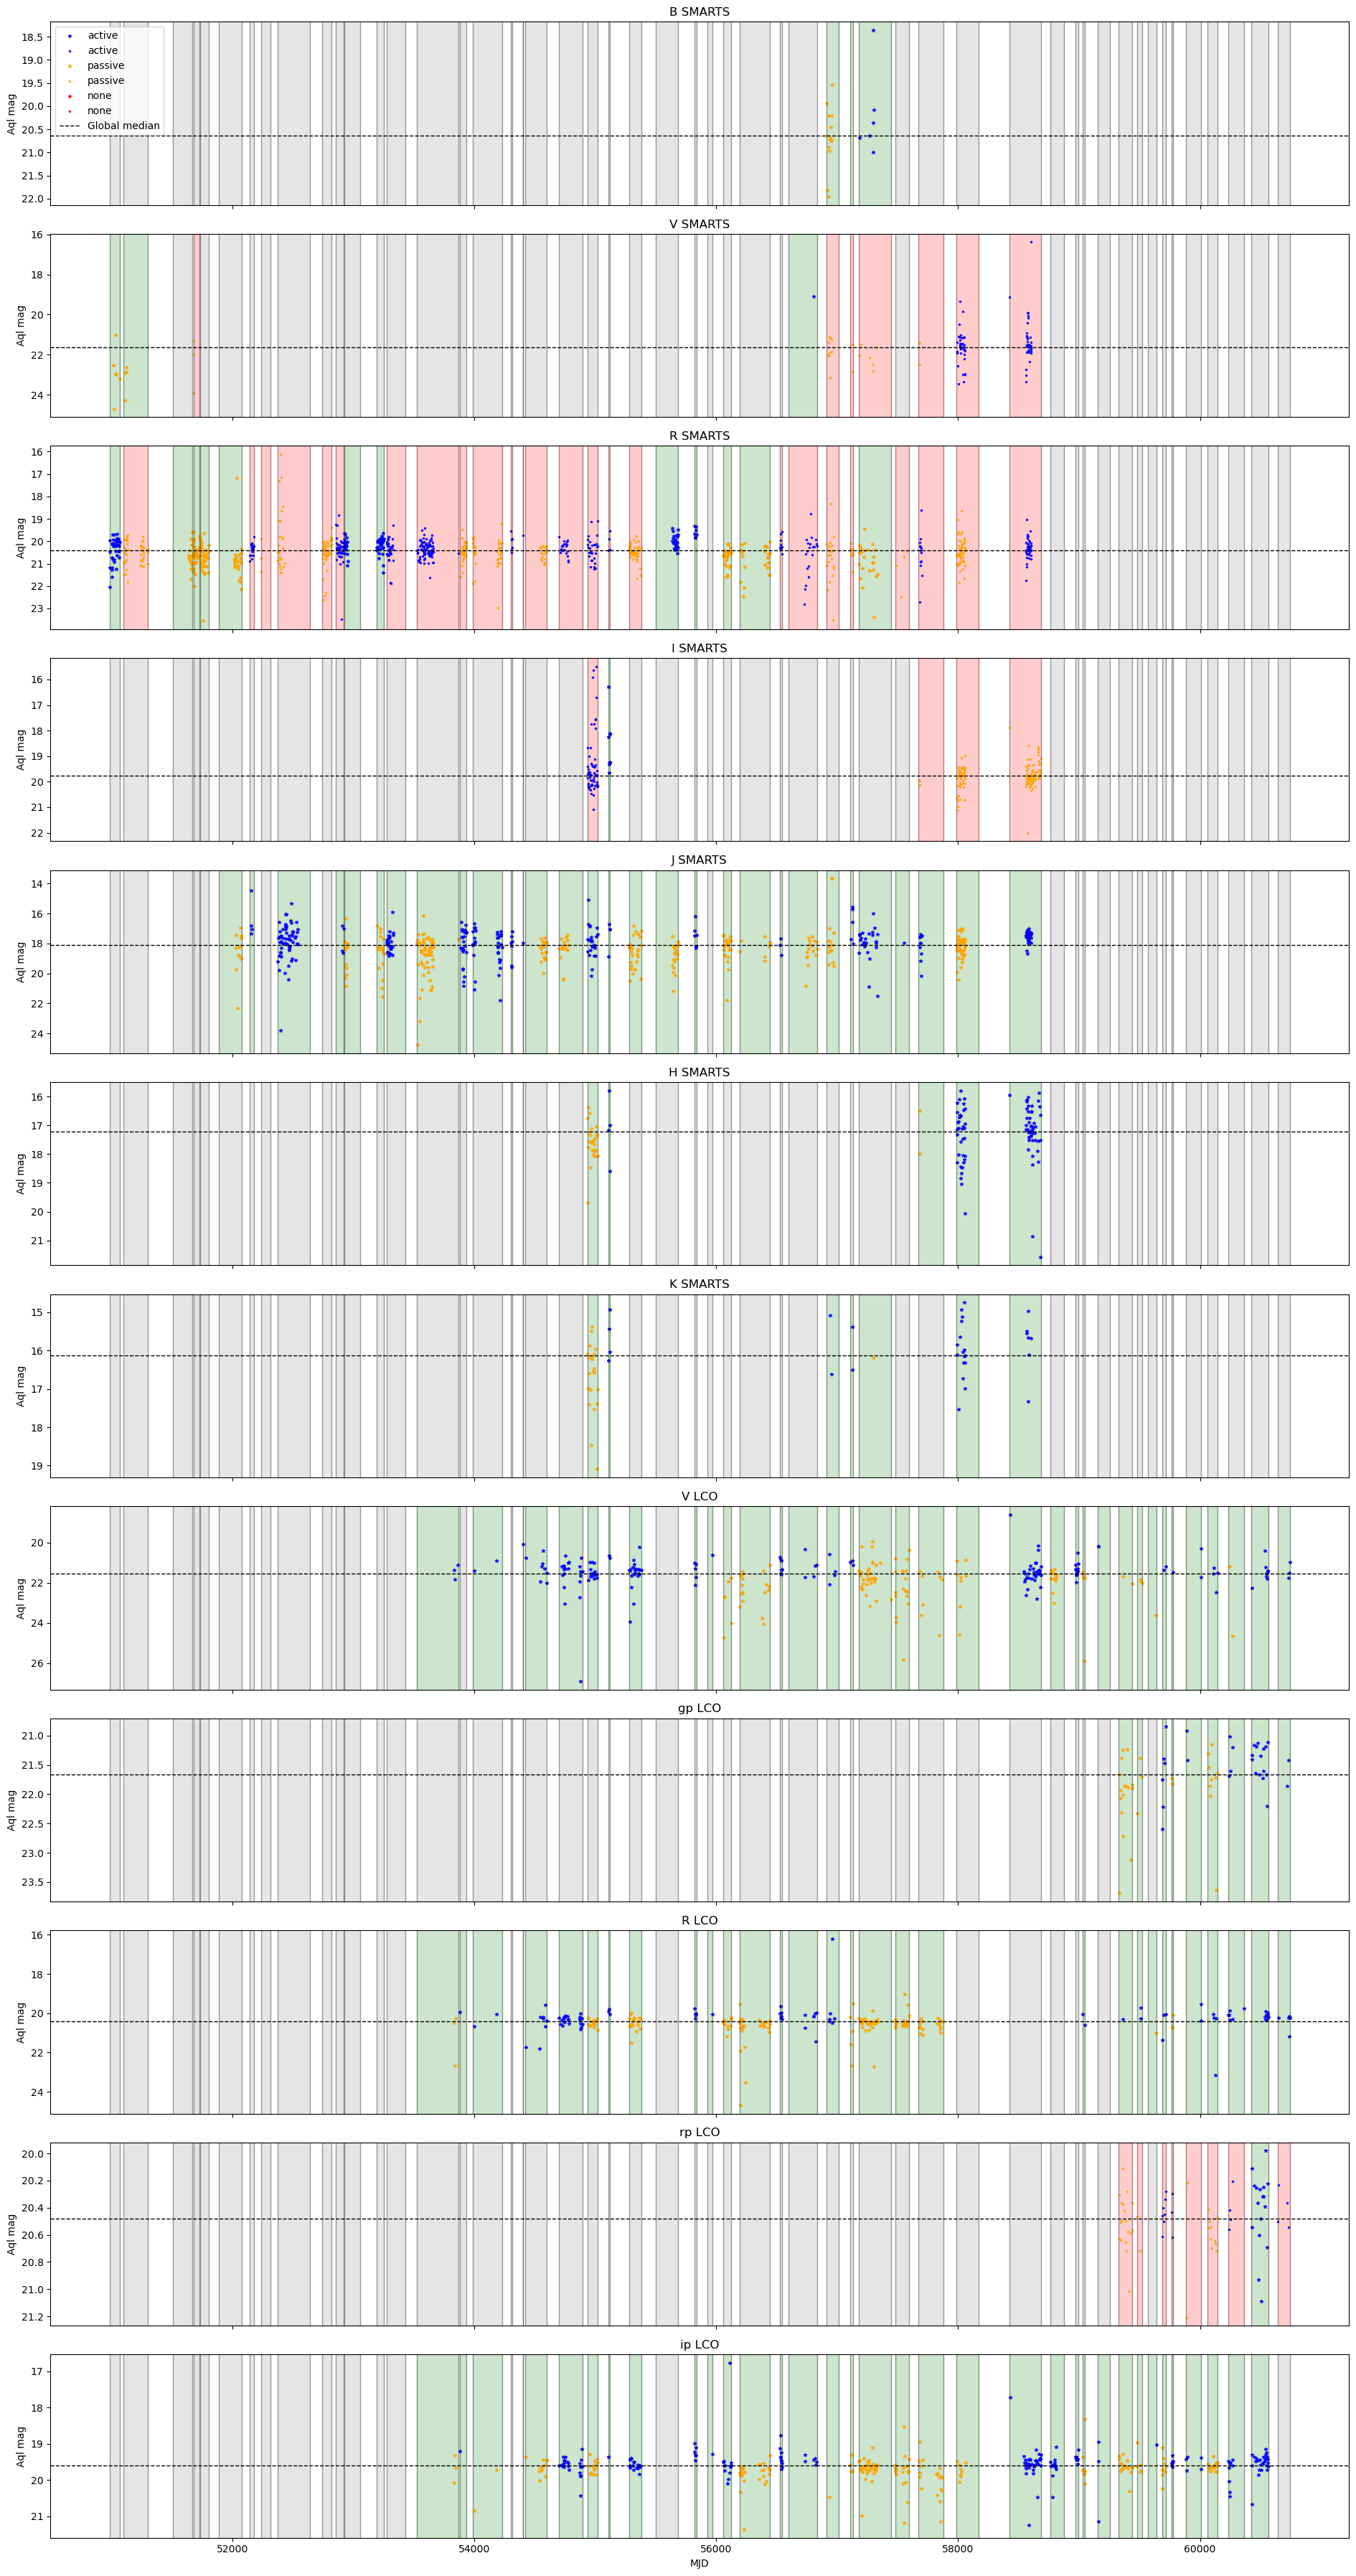

In [11]:
sig_markers = {
    "significant": '*',
    "not significant": '.',
    
}
fig, axes = plt.subplots(len(data), 1, figsize=(19, 3 * len(data)), sharex=True)

if len(data) == 1:
    axes = [axes]

for ax, (key, item) in zip(axes, data.items()):

    df = item["plot_df"]
    print(df.columns)
    
    # ---- shaded epoch regions (per-band significance) ----
    for i, (start, end) in enumerate(quiescent_intervals):
    
        epoch_id = i
    
        sub_epoch = df[df["epoch"] == epoch_id]
    
        if len(sub_epoch) == 0:
            color = "gray"
        else:
            # take dominant sig in epoch (or median decision)
            sig_mode = sub_epoch["sig"].mode()
            sig_mode = sig_mode.iloc[0] if len(sig_mode) > 0 else "not significant"
    
            if sig_mode == "significant":
                color = "green"
            else:
                color = "red"
    
        ax.axvspan(start, end, color=color, alpha=0.2)

    # ---- scatter plot colored by state ----
    for state, color in state_colors.items():
        sub = df[df["state"] == state]
        for sig, marker in sig_markers.items():
            newsub=sub[sub["sig"]==sig]
            ax.scatter(newsub["MJD"], newsub["mag_shifted"],
                       s=10, color=color, marker=marker, label=state, alpha=0.8)

    # ---- vertical epoch boundaries ----
    for start, end in quiescent_intervals:
        ax.axvline(start, color="k", alpha=0.3, linewidth=1)
        ax.axvline(end,   color="k", alpha=0.3, linewidth=1)


    ax.set_title(key)
    ax.set_ylabel("Aql mag")
    ax.invert_yaxis()
    
    ax.axhline(item['global med q mag'], linewidth=1, color='k', linestyle='--',label='Global median')

axes[-1].set_xlabel("MJD")

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend()

plt.tight_layout()
plt.show()

running  B SMARTS
45.89942738425926
DELTA F: 0.002150075842424208
2.67333217488952e-07
9.48
Offset = 20.69914837690805
Amplitude = 0.29574574176166707
Phase shift = 0.30704669273725066
Reduced chi-square: 0.18877987017849862
Linear reduced chi-square: 1.4980070443747644


/tmp/ipykernel_773624/4176127183.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table['nice time']=Time(table['MJD'], format='mjd').to_datetime()
/tmp/ipykernel_773624/4176127183.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = table.groupby('our phase bin')[magstring].agg(['mean','std']).reset_index()
/tmp/ipykernel_773624/4176127183.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

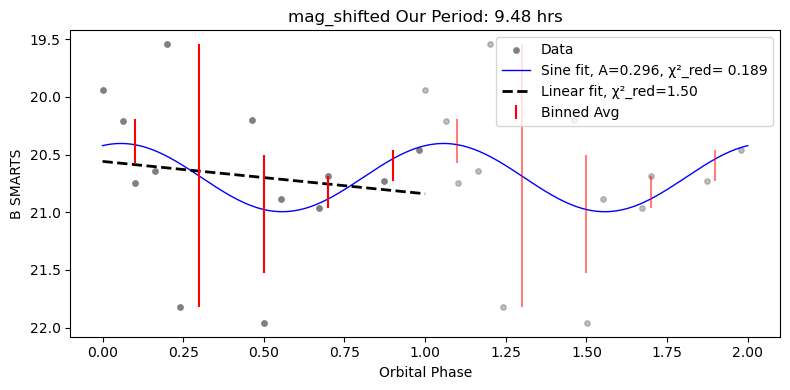

running  V SMARTS
6663.689760671296
DELTA F: 1.4809700562959327e-05
2.67333217488952e-07
9.473589250748832
Offset = 22.334097895808895
Amplitude = -0.3829607823439169
Phase shift = 0.2781995422279953
Reduced chi-square: 1.847971108851633
Linear reduced chi-square: 2.4518507984155904


/tmp/ipykernel_773624/4176127183.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table['nice time']=Time(table['MJD'], format='mjd').to_datetime()
/tmp/ipykernel_773624/4176127183.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = table.groupby('our phase bin')[magstring].agg(['mean','std']).reset_index()
/tmp/ipykernel_773624/4176127183.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

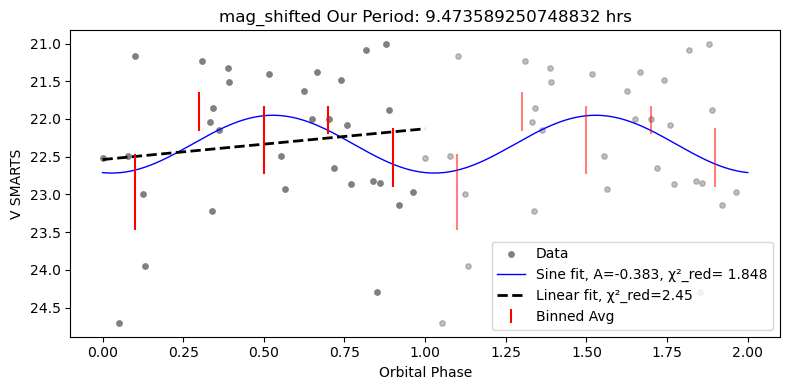

running  R SMARTS
6954.963595162037
DELTA F: 1.4189470390419893e-05
2.67333217488952e-07
9.478215363989532
Offset = 20.586753157674732
Amplitude = 0.11699882542475441
Phase shift = 0.921191211726744
Reduced chi-square: 0.97403954516681
Linear reduced chi-square: 2.4179103491903677


/tmp/ipykernel_773624/4176127183.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table['nice time']=Time(table['MJD'], format='mjd').to_datetime()
/tmp/ipykernel_773624/4176127183.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = table.groupby('our phase bin')[magstring].agg(['mean','std']).reset_index()
/tmp/ipykernel_773624/4176127183.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

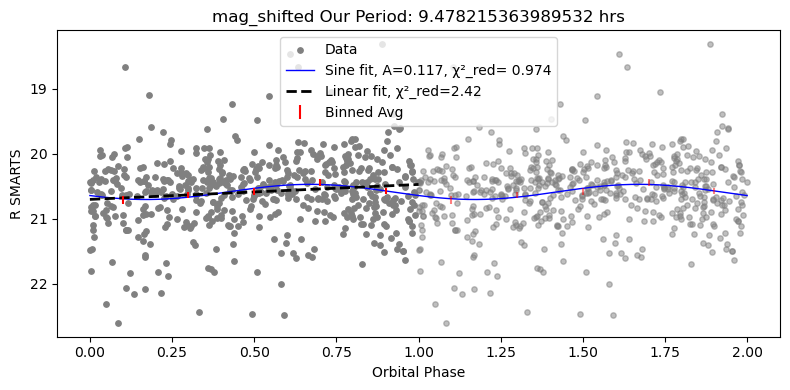

running  I SMARTS
1001.2643100115625
DELTA F: 9.856263627219507e-05
2.67333217488952e-07
9.47722574621144
Offset = 19.775688253231547
Amplitude = 0.15801257305689517
Phase shift = 0.5765711155798628
Reduced chi-square: 2.3903987329030385
Linear reduced chi-square: 4.880437557777931


/tmp/ipykernel_773624/4176127183.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table['nice time']=Time(table['MJD'], format='mjd').to_datetime()
/tmp/ipykernel_773624/4176127183.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = table.groupby('our phase bin')[magstring].agg(['mean','std']).reset_index()
/tmp/ipykernel_773624/4176127183.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

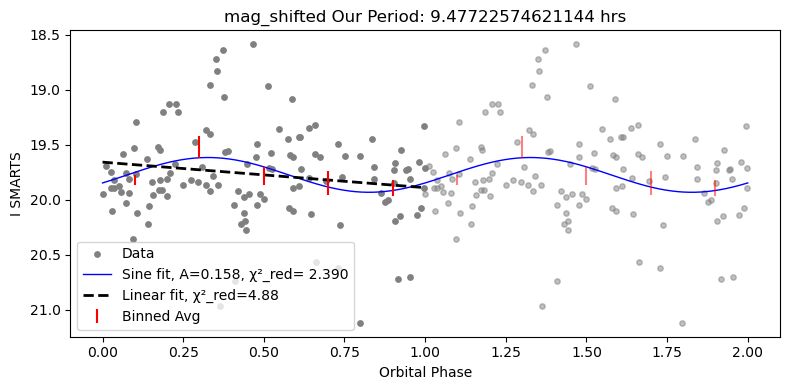

running  J SMARTS
6026.60332755787
DELTA F: 1.6375268892965374e-05
2.67333217488952e-07
9.478660208967188
Offset = 18.474642518792464
Amplitude = 0.19588736578026858
Phase shift = 1.1964853295256188
Reduced chi-square: 0.13763910111154132
Linear reduced chi-square: 1.8644942780305005


/tmp/ipykernel_773624/4176127183.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table['nice time']=Time(table['MJD'], format='mjd').to_datetime()
/tmp/ipykernel_773624/4176127183.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = table.groupby('our phase bin')[magstring].agg(['mean','std']).reset_index()
/tmp/ipykernel_773624/4176127183.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

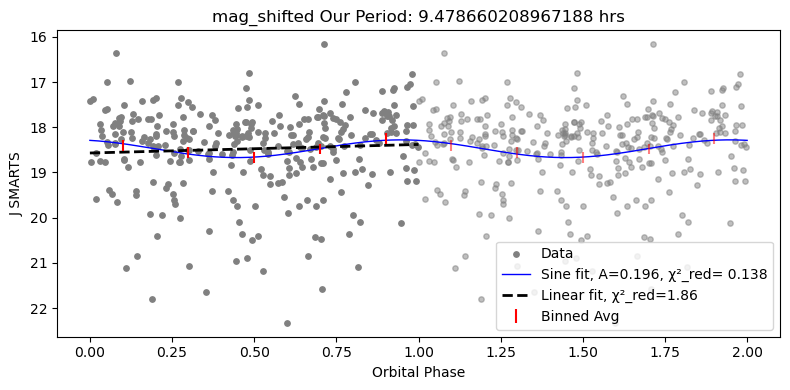

running  H SMARTS
2744.646785335671
DELTA F: 3.595626604023312e-05
2.67333217488952e-07
9.479316293900364
Offset = 17.736906749019035
Amplitude = -0.5544833347297542
Phase shift = 0.34687799373173434
Reduced chi-square: 8.564408850333148
Linear reduced chi-square: 5.052937665285122


/tmp/ipykernel_773624/4176127183.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table['nice time']=Time(table['MJD'], format='mjd').to_datetime()
/tmp/ipykernel_773624/4176127183.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = table.groupby('our phase bin')[magstring].agg(['mean','std']).reset_index()
/tmp/ipykernel_773624/4176127183.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

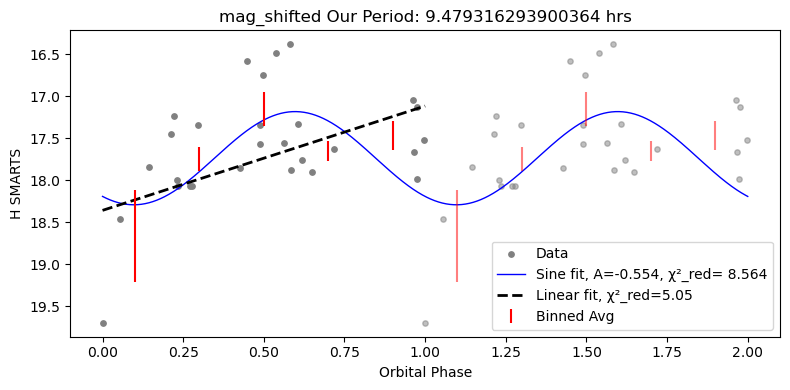

running  K SMARTS
2358.686391597234
DELTA F: 4.183992002988234e-05
2.67333217488952e-07
9.479453928122195
Offset = 16.62987193685463
Amplitude = 0.17071745635263513
Phase shift = 0.17172290313920777
Reduced chi-square: 9464.840309378784
Linear reduced chi-square: 6232.534257535012


/tmp/ipykernel_773624/4176127183.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table['nice time']=Time(table['MJD'], format='mjd').to_datetime()
/tmp/ipykernel_773624/4176127183.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = table.groupby('our phase bin')[magstring].agg(['mean','std']).reset_index()
/tmp/ipykernel_773624/4176127183.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

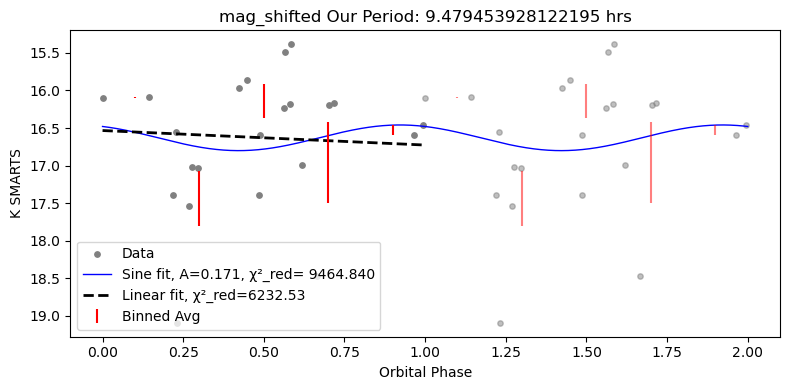

running  V LCO
4204.277984577002
DELTA F: 2.347305538835084e-05
2.67333217488952e-07
9.477275272218879
Offset = 22.027817338145226
Amplitude = 0.27027616952060574
Phase shift = 0.6771091145707995
Reduced chi-square: 0.1810201371212781
Linear reduced chi-square: 1.9428587804937871


/tmp/ipykernel_773624/4176127183.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table['nice time']=Time(table['MJD'], format='mjd').to_datetime()
/tmp/ipykernel_773624/4176127183.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = table.groupby('our phase bin')[magstring].agg(['mean','std']).reset_index()
/tmp/ipykernel_773624/4176127183.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

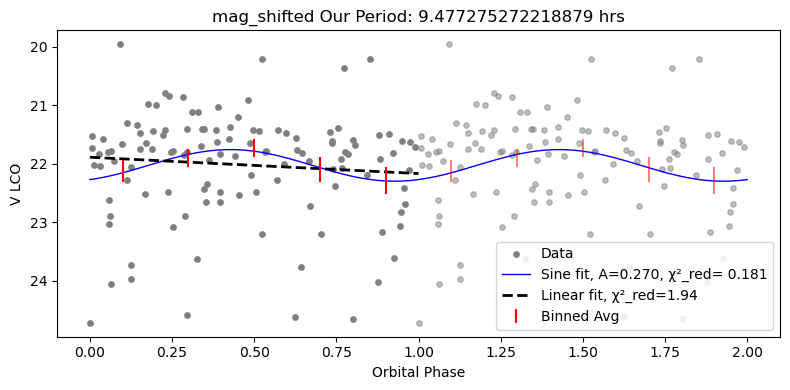

running  gp LCO
811.8348417820022
DELTA F: 0.00012156074723693614
2.67333217488952e-07
9.470356155146293
Offset = 21.918489244471335
Amplitude = 0.45426363676029236
Phase shift = 0.5580260206165176
Reduced chi-square: 0.011439150485762883
Linear reduced chi-square: 3.737667558873379


/tmp/ipykernel_773624/4176127183.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table['nice time']=Time(table['MJD'], format='mjd').to_datetime()
/tmp/ipykernel_773624/4176127183.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = table.groupby('our phase bin')[magstring].agg(['mean','std']).reset_index()
/tmp/ipykernel_773624/4176127183.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

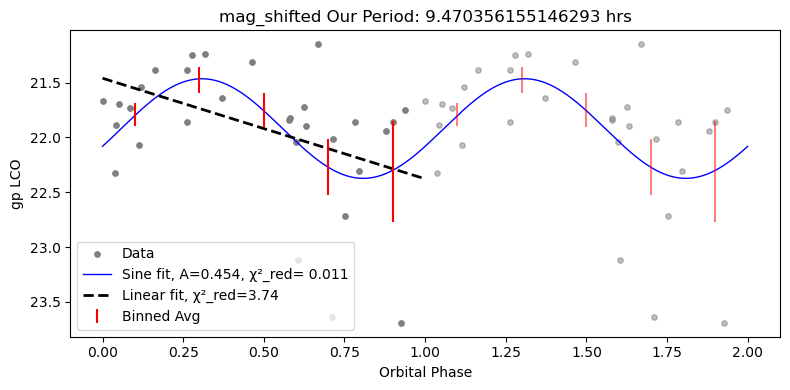

running  R LCO
5942.953953079005
DELTA F: 1.660575713343207e-05
2.67333217488952e-07
9.479662639276691
Offset = 20.50644848132125
Amplitude = -0.08941436128933965
Phase shift = 0.031240882661317596
Reduced chi-square: 4.590512524759104
Linear reduced chi-square: 1.3897100862587972


/tmp/ipykernel_773624/4176127183.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table['nice time']=Time(table['MJD'], format='mjd').to_datetime()
/tmp/ipykernel_773624/4176127183.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = table.groupby('our phase bin')[magstring].agg(['mean','std']).reset_index()
/tmp/ipykernel_773624/4176127183.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

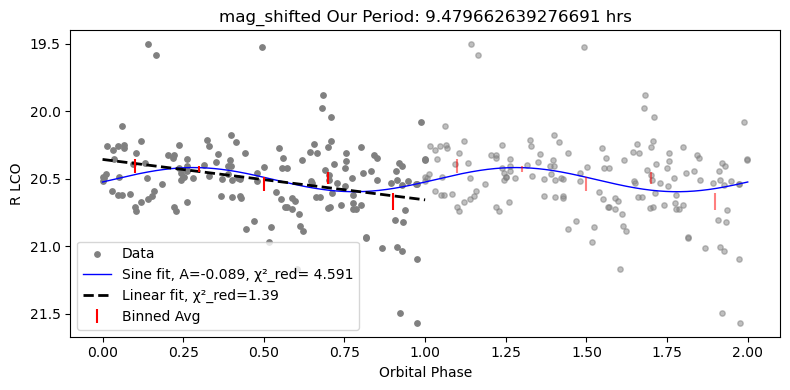

running  rp LCO
811.834841978993
DELTA F: 0.00012156074720743955
2.67333217488952e-07
9.47
Offset = 20.520099367435353
Amplitude = -0.1425102315262072
Phase shift = 0.1297013792309129
Reduced chi-square: 0.06787507082660518
Linear reduced chi-square: 5.467257022463328


/tmp/ipykernel_773624/4176127183.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table['nice time']=Time(table['MJD'], format='mjd').to_datetime()
/tmp/ipykernel_773624/4176127183.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = table.groupby('our phase bin')[magstring].agg(['mean','std']).reset_index()
/tmp/ipykernel_773624/4176127183.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

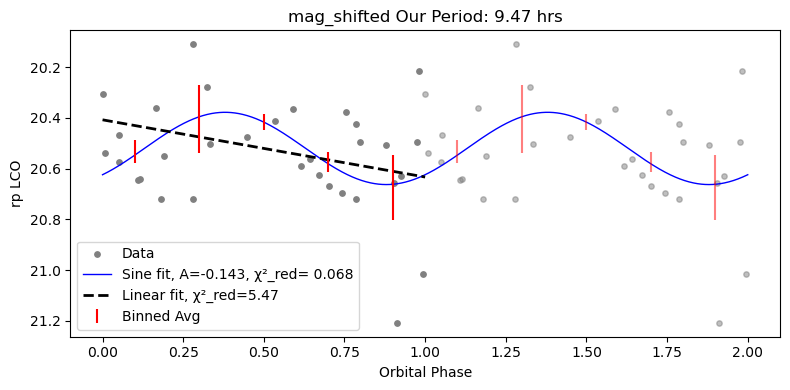

running  ip LCO
6309.218554930012
DELTA F: 1.564175486089097e-05
2.67333217488952e-07
9.47018831432049
Offset = 19.707367668441908
Amplitude = 0.07972376049013415
Phase shift = 0.777869437624076
Reduced chi-square: 0.6427022238260062
Linear reduced chi-square: 4.418823669434878


/tmp/ipykernel_773624/4176127183.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table['nice time']=Time(table['MJD'], format='mjd').to_datetime()
/tmp/ipykernel_773624/4176127183.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = table.groupby('our phase bin')[magstring].agg(['mean','std']).reset_index()
/tmp/ipykernel_773624/4176127183.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

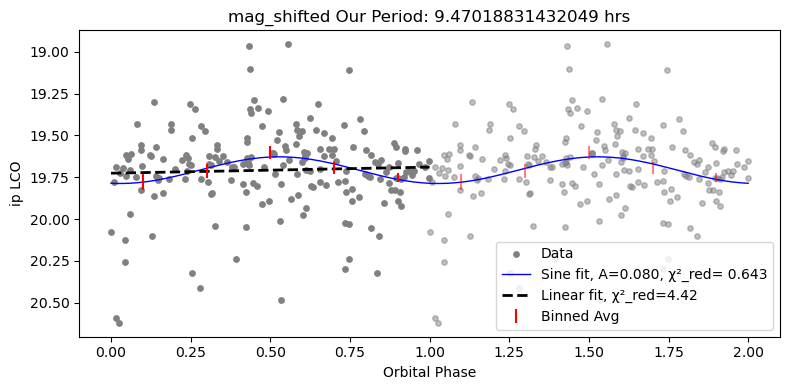

In [12]:
for key in data:

    print('running ', key)
    table=data[key]['plot_df']
    
    #get only passive
    table = table[table["state"] == 'passive']
    table['nice time']=Time(table['MJD'], format='mjd').to_datetime()
    maglabel=key
    magstring='mag_shifted'
    #upper=19
    #lower=22
    #table=table.loc[(table[magstring]>upper) & (table[magstring]<lower)]
    #sigma clip
    mag = table[magstring]
    
    # drop NaNs FIRST
    mag = mag.dropna()
    table = table.loc[mag.index].copy()
    
    center = np.median(mag)
    
    s68 = 0.5 * (np.percentile(mag, 84.13) - np.percentile(mag, 15.87))
    
    # safety check
    if not np.isfinite(s68) or s68 == 0:
        print(key, "bad s68 =", s68, "→ skipping clipping")
    else:
        mask = np.abs(mag - center) <= 5 * s68
        table = table.loc[mask].copy()
    
    
    #periodogramming things
    baseline=table['nice time'].max()-table['nice time'].min()
    base_days=baseline.total_seconds() / 3600 /24
    print(base_days)
    
    #folded??
    P = 0.789498/2  # period in days
    times = Time(table['nice time']).mjd
    t0 = times.min()
    phase = ((times - t0) / P) % 1
    table['their phase']=phase
    
    ##periodograms
    min_frequency = 2*24/18.96
    max_frequency = 2*24/18.94
    
    deltaf=P/base_days/4
    print('DELTA F:', deltaf)
    print(np.abs(min_frequency-max_frequency)/10000)
    
    frequency = np.linspace(min_frequency, max_frequency, 20000)#np.arange(min_frequency, max_frequency, deltaf)
    
    fall, pall = LombScargle(times, table[magstring]-np.nanmean(table[magstring])).autopower(maximum_frequency=2)
    power = LombScargle(times, table[magstring]-np.nanmean(table[magstring])).power(frequency)
    
    # Convert frequency to period in hours
    period_hours = 24 / frequency
    sorted_idx = np.argsort(period_hours)
    period_hours_sorted = period_hours[sorted_idx]
    power_sorted = power[sorted_idx]
    '''
    # Plot periodogram in period units
    plt.figure(figsize=(8,4))
    plt.plot(period_hours_sorted, power_sorted)
    plt.xlabel('Period (hours)')
    plt.ylabel('Power')
    plt.title('Lomb-Scargle Periodogram')
    plt.axvline(x=P*24/2,alpha=0.5, color='red')
    plt.savefig(f'/home/kmc249/folded_curves/{key}_periodogram.png')
    plt.show(block=False)
    
    fig, ax = plt.subplots(figsize=(8,4))
    ax.plot(frequency, power)
    plt.show(block=False)
    '''
    # samme thing for fall pall
    pall_hours = 24 / fall
    sorted_idxall = np.argsort(pall_hours)
    period_hours_sortedall = pall_hours[sorted_idxall]
    power_sortedall = pall[sorted_idxall]
    
    # Plot periodogram in period units
    '''
    plt.figure(figsize=(8,4))
    plt.plot(period_hours_sortedall, power_sortedall)
    plt.xlabel('Period (hours)')
    plt.ylabel('Power')
    plt.title('Lomb-Scargle Periodogram (all freq, capped)')
    plt.axvline(x=P*24,alpha=0.5, color='red')
    plt.xlim(12, 45)
    plt.show(block=False)
    '''
    '''
    fig, ax = plt.subplots()
    ax.plot(fall, pall)
    plt.show(block=False)
    '''
    best_frequency = frequency[np.argmax(power)]
    P2 = 1 / best_frequency
    best_period_hours = P2 * 24
    print(best_period_hours)
    
    phase2 = ((times - t0) / P2) % 1
    table['our phase']=phase2
    
    # Number of bins
    nbins = 5
    bins = np.linspace(0, 1, nbins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    
    # Assign each phase to a bin
    table['our phase bin'] = pd.cut(table['our phase'], bins=bins, include_lowest=True, labels=bin_centers)
    table['their phase bin'] = pd.cut(table['their phase'], bins=bins, include_lowest=True, labels=bin_centers)
    
    # Compute mean and std per bin
    binned = table.groupby('our phase bin')[magstring].agg(['mean','std']).reset_index()
    binned_them = table.groupby('their phase bin')[magstring].agg(['mean','std']).reset_index()
    
    binned = table.groupby('our phase bin')[magstring].agg(
        mean='mean',
        std='std',
        count='count'
    ).reset_index()
    
    binned_them = table.groupby('their phase bin')[magstring].agg(
        mean='mean',
        std='std',
        count='count'
    ).reset_index()
    
    binned['sem'] = binned['std'] / np.sqrt(binned['count'])
    binned_them['sem'] = binned_them['std'] / np.sqrt(binned_them['count'])
    
    yerr_us = binned['sem'].values
    yerr_them = binned_them['sem'].values
    
    def sine_model(phi, offset, amplitude, phase_shift):
        return offset + amplitude * np.sin(2*np.pi*(phi - phase_shift))
    
    def linear_model(x, m, b):
        return m * x + b
    
    x = binned['our phase bin'].astype(float).values
    y = binned['mean'].values
    
    # remove NaNs
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    
    # initial guesses
    offset0 = np.mean(y)
    amp0 = (np.max(y) - np.min(y)) / 2
    phase0 = x[np.argmin(y)]   # minimum mag = brightest
    
    popt, pcov = curve_fit(
        sine_model,
        x,
        y,
        p0=[offset0, amp0, phase0]
    )
    
    popt_lin, pcov_lin = curve_fit(
        linear_model,
        x,
        y,
        p0=[0, np.mean(y)]
    )
    
    m_fit, b_fit = popt_lin
    
    offset_fit, amp_fit, phase_fit = popt
    
    print("Offset =", offset_fit)
    print("Amplitude =", amp_fit)
    print("Phase shift =", phase_fit)
    phi_fit = np.linspace(0, 2, 1000)

    y_fit = sine_model(phi_fit % 1, *popt)
    
    #chi^2 red
    y_fit2 = sine_model(binned['our phase bin'].astype(float), *popt)
    residuals = binned['mean'] - y_fit2

    chi2 = np.sum((residuals / yerr_us) ** 2)
    dof = len(x) - len(popt)
    chi2_red = chi2 / dof
    
    print("Reduced chi-square:", chi2_red)
    
    y_lin = linear_model(binned['our phase bin'].astype(float).values, *popt_lin)
    res_lin = binned['mean'] - y_lin
    
    chi2_lin = np.sum((res_lin / yerr_us) ** 2)
    dof_lin = len(x) - len(popt_lin)
    chi2_red_lin = chi2_lin / dof_lin
    
    print("Linear reduced chi-square:", chi2_red_lin)
    x_fit = np.linspace(0, 1, 500)
    y_lin_fit = linear_model(x_fit, *popt_lin)
    
    # Plot with asymmetric error bars
    plt.figure(figsize=(8,4))
    plt.scatter(phase2, table[magstring], s=15, color='gray', label='Data')
    plt.scatter(phase2 + 1, table[magstring], s=15, color='gray', alpha=0.5)
    plt.plot(phi_fit, y_fit, 'b-', lw=1, label=f'Sine fit, A={amp_fit:.3f}, χ²_red= {chi2_red:.3f}')
    plt.plot(x_fit, y_lin_fit, 'k--', lw=2, label=f'Linear fit, χ²_red={chi2_red_lin:.2f}')
    plt.errorbar(binned['our phase bin'].astype(float), binned['mean'], yerr=yerr_us,
                 fmt='none', color='red', label='Binned Avg')
    plt.errorbar(binned['our phase bin'].astype(float)+1, binned['mean'], yerr=yerr_us,
                 fmt='none', color='red', alpha=0.5)
    
    plt.xlabel('Orbital Phase')
    plt.ylabel(maglabel)
    plt.gca().invert_yaxis()
    plt.title(f'{magstring} Our Period: {best_period_hours} hrs')
    plt.legend()
    plt.tight_layout()
    #plt.savefig(f'/home/kmc249/Downloads/{maglabel}_passive_count_mini.png')
    
    plt.show(block=False)
    '''
    
    # Plot
    plt.figure(figsize=(8,4))
    plt.scatter(phase, table[magstring], s=15, color='gray', label='Data')
    plt.scatter(phase + 1, table[magstring], s=15, color='gray', alpha=0.5)
    
    plt.errorbar(binned_them['their phase bin'].astype(float), binned_them['mean'], yerr=yerr_them,
                 fmt='.', color='red', label='Binned Avg')
    plt.errorbar(binned_them['their phase bin'].astype(float)+1, binned_them['mean'], yerr=yerr_them,
                 fmt='.', color='red', alpha=0.5)
    
    plt.xlabel('Orbital Phase')
    plt.ylabel(maglabel)
    plt.gca().invert_yaxis()
    plt.legend()
    plt.title(f'{magstring} Their Period: {P*24} hrs')
    plt.tight_layout()
    plt.show()
    '''

In [55]:
for key in data:
    print(key)

B SMARTS
V SMARTS
R SMARTS
I SMARTS
J SMARTS
H SMARTS
K SMARTS
V LCO
gp LCO
R LCO
rp LCO
ip LCO


Best period (hours): 18.956169434722526
   phase_bin      mean       std  count  n_total  n_outliers  frac_outliers
0      0.025 -0.073979  0.442513    128      128           0       0.000000
1      0.075  0.028571  0.380130    139      139           0       0.000000
2      0.125 -0.043006  0.406229    142      142           0       0.000000
3      0.175 -0.009035  0.374303    115      115           0       0.000000
4      0.225  0.039249  0.410309    145      145           0       0.000000
5      0.275 -0.021538  0.381530    146      146           0       0.000000
6      0.325 -0.001437  0.353662    136      136           1       0.007353
7      0.375  0.006694  0.386487    142      142           0       0.000000
8      0.425 -0.009359  0.431581    125      125           0       0.000000
9      0.475 -0.061054  0.361758    141      141           1       0.007092
10     0.525 -0.072309  0.367941    156      156           1       0.006410
11     0.575 -0.081796  0.396198    124      124

/tmp/ipykernel_773624/270008357.py:121: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("phase_bin")
/tmp/ipykernel_773624/270008357.py:122: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sigma_clip_counts, col="mag_centered", nsig=3)
/tmp/ipykernel_773624/270008357.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence thi

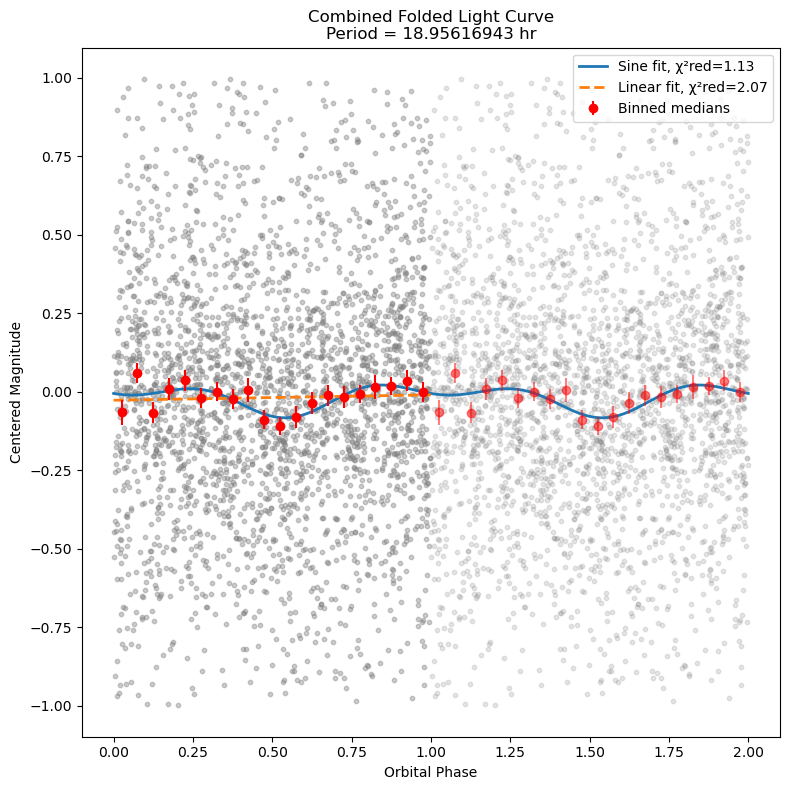

In [157]:


combined = []

for key in data:

    df = data[key]["plot_df"].copy()

    # same filtering as before
    #df = df[df["state"] == "passive"]

    # remove NaNs
    df = df[np.isfinite(df["mag_shifted"])]

    # subtract mean (or median)
    df["mag_centered"] = (
        df["mag_shifted"]
        - df["mag_shifted"].median()
    )

    combined.append(
        df[["MJD", "mag_centered", "mag_corr_err"]]
    )

combined = pd.concat(combined, ignore_index=True)



min_frequency = 24/18.96
max_frequency = 24/18.94

frequency = np.linspace(
    min_frequency,
    max_frequency,
    80000
)

ls = LombScargle(
    combined["MJD"].values,
    combined["mag_centered"].values,
    dy=combined["mag_corr_err"].values
)

power = ls.power(frequency)

best_frequency = frequency[np.argmax(power)]
best_period = 24 / best_frequency

#get rid of crazy crazy outliers
combined=combined.loc[(combined['mag_centered']>-1)&(combined['mag_centered']<1)]

print("Best period (hours):", best_period)

P2 = 1 / best_frequency  # days

times = combined["MJD"].values

t0 = times.min()

phase = ((times - t0) / P2) % 1

combined["phase"] = phase

nbins = 20

bins = np.linspace(0, 1, nbins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

combined["phase_bin"] = pd.cut(
    combined["phase"],
    bins=bins,
    include_lowest=True,
    labels=bin_centers
)



#sigma clip
mag = combined['mag_centered']

# drop NaNs FIRST
mag = mag.dropna()


table = combined.loc[mag.index].copy()

def sigma_clip_group(df, col, nsig=1):
    x = df[col].dropna()

    if len(x) == 0:
        return df.iloc[0:0]

    center = np.median(x)
    s68 = 0.5 * (np.percentile(x, 84.13) - np.percentile(x, 15.87))

    if s68 == 0:
        return df.loc[x.index]  # nothing to clip

    mask = np.abs(df[col] - center) <= nsig * s68
    return df.loc[mask]

def sigma_clip_counts(df, col, nsig=1):
    x = df[col]

    center = np.median(x)
    s68 = 0.5 * (np.percentile(x, 84.13) - np.percentile(x, 15.87))

    if s68 == 0 or len(x) == 0:
        return pd.Series({
            "n_total": len(x),
            "n_outliers": 0
        })

    mask = np.abs(x - center) <= nsig * s68

    return pd.Series({
        "n_total": len(x),
        "n_outliers": (~mask).sum()
    })

outlier_counts = (
    combined
    .groupby("phase_bin")
    .apply(sigma_clip_counts, col="mag_centered", nsig=3)
    .reset_index()
)

outlier_counts["frac_outliers"] = (
    outlier_counts["n_outliers"] / outlier_counts["n_total"]
)

binned = combined.groupby("phase_bin")["mag_centered"].agg(
    mean="mean",
    std="std",
    count="count"
).reset_index()

binned = binned.merge(outlier_counts, on="phase_bin", how="left")

print(
    binned.sort_values("phase_bin")[[
        "phase_bin", "mean", "std", "count",
        "n_total", "n_outliers", "frac_outliers"
    ]]
)

#do the sigma clipped
combined_clipped = (
    combined
    .groupby("phase_bin", group_keys=False)
    .apply(lambda g: sigma_clip_group(g, "mag_centered", nsig=3))
)

phase=combined["phase"]

binned = combined_clipped.groupby("phase_bin")["mag_centered"].agg(
    mean="mean",
    std="std",
    count="count",
    median='median'
).reset_index()

binned["sem"] = binned["std"] / np.sqrt(binned["count"])
'''
def sine_model(phi, offset, amplitude, phase_shift):
    return offset + amplitude * np.sin(
        2*np.pi*(phi - phase_shift)
    )
'''

def sine_model(phi,
                offset,
                amp1,
                phase1,
                amp2,
                phase2):

    return (
        offset
        + amp1 * np.sin(2*np.pi*(phi - phase1))
        + amp2 * np.sin(4*np.pi*(phi - phase2))
    )

def linear_model(x, m, b):
    return m*x + b

x = binned["phase_bin"].astype(float).values
y = binned["median"].values

mask = np.isfinite(x) & np.isfinite(y)

x = x[mask]
y = y[mask]

yerr = binned["sem"].values[mask]

offset0 = np.mean(y)

amp10 = (np.max(y) - np.min(y))/4
amp20 = amp10/2

phase10 = 0
phase20 = 0

popt, pcov = curve_fit(
    sine_model,
    x,
    y,
    sigma=yerr,
    absolute_sigma=True,
    p0=[
        offset0,
        amp10,
        phase10,
        amp20,
        phase20
    ]
)

popt_lin, pcov_lin = curve_fit(
    linear_model,
    x,
    y,
    sigma=yerr,
    absolute_sigma=True,
    p0=[0, np.mean(y)]
)

y_fit_bins = sine_model(x, *popt)

chi2 = np.sum(
    ((y - y_fit_bins)/yerr)**2
)

chi2_red = chi2 / (len(y) - len(popt))

y_lin_bins = linear_model(x, *popt_lin)

chi2_lin = np.sum(
    ((y - y_lin_bins)/yerr)**2
)

chi2_red_lin = (
    chi2_lin /
    (len(y) - len(popt_lin))
)

y_lin_bins = linear_model(x, *popt_lin)

chi2_lin = np.sum(
    ((y - y_lin_bins)/yerr)**2
)

chi2_red_lin = (
    chi2_lin /
    (len(y) - len(popt_lin))
)

phi_fit = np.linspace(0, 2, 1000)

y_sine = sine_model(
    phi_fit % 1,
    *popt
)

x_fit = np.linspace(0, 1, 500)

y_line = linear_model(
    x_fit,
    *popt_lin
)

plt.figure(figsize=(8,8))

# raw folded points
plt.scatter(
    phase,
    combined["mag_centered"],
    s=10,
    color="gray",
    alpha=0.4
)

plt.scatter(
    phase + 1,
    combined["mag_centered"],
    s=10,
    color="gray",
    alpha=0.2
)

# sine fit
plt.plot(
    phi_fit,
    y_sine,
    lw=2,
    label=f"Sine fit, χ²red={chi2_red:.2f}"
)

# line fit
plt.plot(
    x_fit,
    y_line,
    "--",
    lw=2,
    label=f"Linear fit, χ²red={chi2_red_lin:.2f}"
)

# binned averages
plt.errorbar(
    x,
    y,
    yerr=yerr,
    fmt="o",
    label="Binned medians",
    color='red'
)

plt.errorbar(
    x + 1,
    y,
    yerr=yerr,
    fmt="o",
    alpha=0.5,
    color='red'
)

plt.xlabel("Orbital Phase")
plt.ylabel("Centered Magnitude")
plt.title(
    f"Combined Folded Light Curve\n"
    f"Period = {best_period:.8f} hr"
)

plt.legend()
plt.tight_layout()
plt.show()

In [19]:


def sinusoid(t, A, w, phi, c):
    return A * np.sin(2*np.pi*t*w + phi) + c

t_obs = []
phase_shifts = []

window = 200  # days or adjust

for start in np.arange(combined["MJD"].min(), combined["MJD"].max(), window):

    df = combined[(combined["MJD"] >= start) & (combined["MJD"] < start + window)]
    if len(df) < 50:
        continue

    t = df["MJD"].values
    y = df["mag_centered"].values

    # fold using expected frequency
    P0 = best_period
    phase = (t % P0) / P0

    # fit sinusoid in phase space
    def model(phase, A, phi, c):
        return A*np.sin(2*np.pi*phase + phi) + c

    popt, _ = curve_fit(model, phase, y, p0=[0.1, 0, np.mean(y)])

    phi_fit = popt[1]

    # convert phase shift -> time shift
    t_mid = np.mean(t)
    t_obs.append(t_mid)
    phase_shifts.append(phi_fit)

18.947952

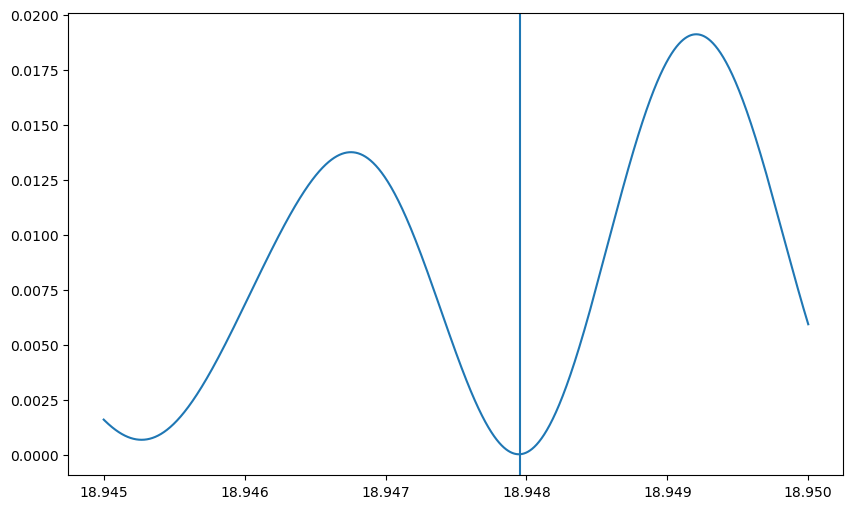

In [54]:
plt.figure(figsize=(10,6))
plt.plot(24/frequency, power)
plt.axvline(2*P*24)
plt.show()

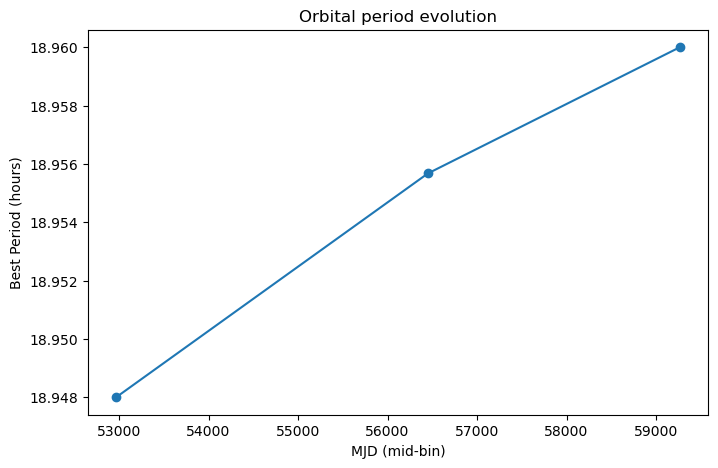

Pdot (days/day): 7.984795821767122e-08
Pdot (s/s): 0.006898863590006793


In [70]:
#pdot stuff

t0 = combined["MJD"].min()
combined["year"] = (combined["MJD"] - t0) / 365.25

bin_width = 10.0  # years

combined["year_bin"] = np.floor(combined["year"] / bin_width)


results = []

for ybin, df in combined.groupby("year_bin"):

    if len(df) < 50:
        continue  # avoid junk statistics

    t = df["MJD"].values
    y = df["mag_centered"].values
    dy = df["mag_corr_err"].values

    ls = LombScargle(t, y, dy)

    power = ls.power(frequency)
    best_freq = frequency[np.argmax(power)]
    best_period = 1 / best_freq

    results.append({
        "year_bin": ybin,
        "t_mid": t.mean(),
        "P_best": best_period,
        "n_points": len(df)
    })

results = pd.DataFrame(results)

plt.figure(figsize=(8,5))

plt.errorbar(
    results["t_mid"],
    results["P_best"] * 24,   # days → hours if needed
    yerr=None,
    fmt="o-"
)

plt.xlabel("MJD (mid-bin)")
plt.ylabel("Best Period (hours)")
plt.title("Orbital period evolution")
plt.show()

from scipy.optimize import curve_fit

def lin(t, a, b):
    return a*t + b

popt, pcov = curve_fit(lin, results["t_mid"], results["P_best"])

Pdot = popt[0]  # days/day

print("Pdot (days/day):", Pdot)
print("Pdot (s/s):", Pdot * 86400)

In [151]:
def get_period_evolution(combined, frequency, bin_width):
    min_frequency = 24/18.96
    max_frequency = 24/18.94
    
    frequency = np.linspace(
        min_frequency,
        max_frequency,
        100000
    )

    df = combined.copy()

    t0 = df["MJD"].min()
    df["year"] = (df["MJD"] - t0) / 365.25

    df["year_bin"] = np.floor(df["year"] / bin_width)

    results = []

    for ybin, g in df.groupby("year_bin"):

        if len(g) < 50:
            continue

        t = g["MJD"].values
        y = g["mag_centered"].values
        dy = g["mag_corr_err"].values

        ls = LombScargle(t, y, dy)

        power = ls.power(frequency)
        best_freq = frequency[np.argmax(power)]
        best_period = 1 / best_freq

        results.append({
            "bin_width": bin_width,
            "t_mid": t.mean(),
            "P_best": best_period,
            "n_points": len(g)
        })

    return pd.DataFrame(results)

In [152]:
bin_widths = [1, 2, 5, 10, 15, 30]

all_results = []

for bw in bin_widths:
    res = get_period_evolution(combined, frequency, bw)
    all_results.append(res)

all_results = pd.concat(all_results, ignore_index=True)

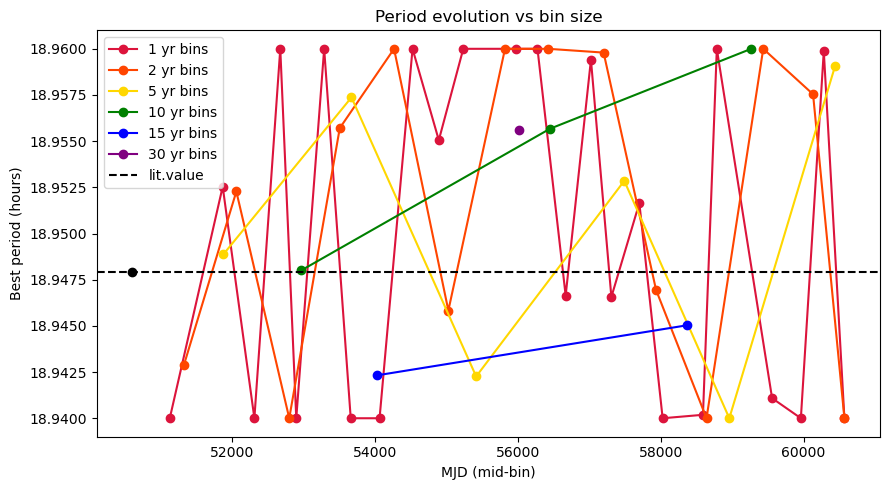

In [153]:
plt.figure(figsize=(9,5))

colors = ["crimson", "orangered", "gold", "green", "blue", "purple"]

for bw, col in zip(bin_widths, colors):

    sub = all_results[all_results["bin_width"] == bw]

    plt.plot(
        sub["t_mid"],
        sub["P_best"] * 24,
        marker="o",
        color=col,
        label=f"{bw} yr bins"
    )
plt.axhline(18.9479, label='lit.value', color='k',linestyle='dashed')
plt.scatter(50607, 18.9479, color = 'k', marker='o')

plt.xlabel("MJD (mid-bin)")
plt.ylabel("Best period (hours)")
plt.title("Period evolution vs bin size")
plt.legend()
plt.tight_layout()
plt.show()

In [155]:
all_results["diff"] = np.abs(all_results["P_best"] * 24 - 18.9479)
best_row = all_results.loc[all_results["diff"].idxmin()]
print(best_row)

best_bw = best_row["bin_width"]

best_subset = combined.copy()

t0 = best_subset["MJD"].min()
best_subset["year"] = (best_subset["MJD"] - t0) / 365.25
best_subset["year_bin"] = np.floor(best_subset["year"] / best_bw)


bin_width       10.000000
t_mid        52968.345491
P_best           0.789500
n_points       844.000000
diff             0.000104
Name: 44, dtype: float64


/tmp/ipykernel_773624/1283538583.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("phase_bin")
/tmp/ipykernel_773624/1283538583.py:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sigma_clip_counts, col="mag_centered", nsig=3)
/tmp/ipykernel_773624/1283538583.py:79: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence thi

   phase_bin      mean       std  count  n_total  n_outliers  frac_outliers
0    0.03125 -0.075850  0.427498    172      172           0       0.000000
1    0.09375  0.018813  0.403047    168      168           0       0.000000
2    0.15625 -0.060370  0.394499    141      141           0       0.000000
3    0.21875 -0.018100  0.407787    193      193           0       0.000000
4    0.28125  0.029511  0.411434    157      157           0       0.000000
5    0.34375  0.020765  0.340575    174      174           3       0.017241
6    0.40625 -0.023658  0.403723    180      180           0       0.000000
7    0.46875 -0.027490  0.382607    155      155           0       0.000000
8    0.53125  0.028096  0.363705    182      182           0       0.000000
9    0.59375  0.012284  0.420154    186      186           0       0.000000
10   0.65625 -0.037311  0.396657    187      187           1       0.005348
11   0.71875  0.007239  0.381686    181      181           0       0.000000
12   0.78125

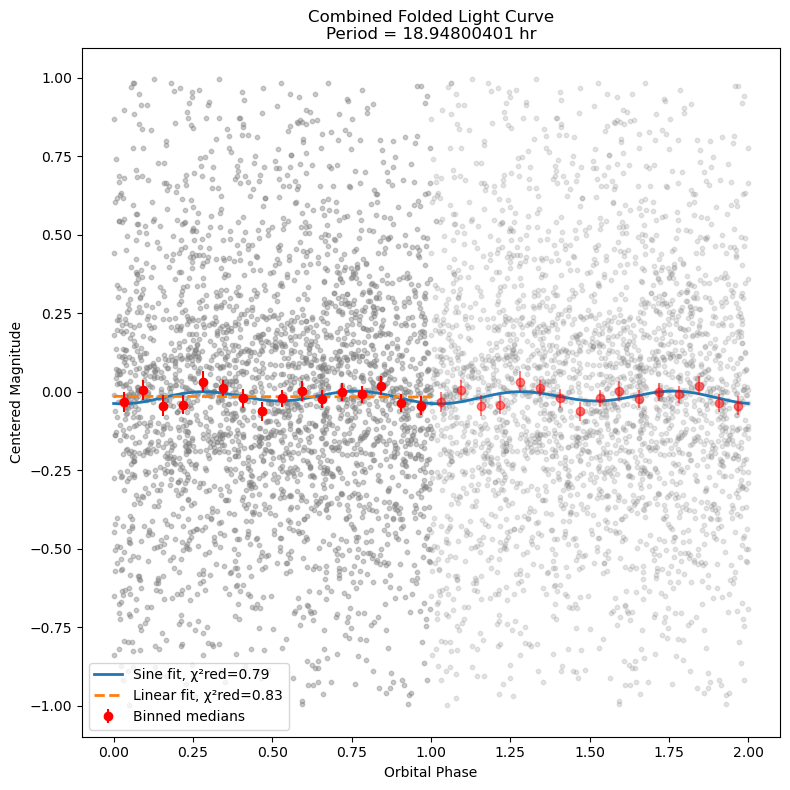

In [156]:
combined=best_subset

times = combined["MJD"].values

t0 = times.min()

phase = ((times - t0) / (best_row['P_best'])) % 1

combined["phase"] = phase

nbins = 16

bins = np.linspace(0, 1, nbins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

combined["phase_bin"] = pd.cut(
    combined["phase"],
    bins=bins,
    include_lowest=True,
    labels=bin_centers
)



#sigma clip
mag = combined['mag_centered']

# drop NaNs FIRST
mag = mag.dropna()


table = combined.loc[mag.index].copy()

def sigma_clip_group(df, col, nsig=1):
    x = df[col].dropna()

    if len(x) == 0:
        return df.iloc[0:0]

    center = np.median(x)
    s68 = 0.5 * (np.percentile(x, 84.13) - np.percentile(x, 15.87))

    if s68 == 0:
        return df.loc[x.index]  # nothing to clip

    mask = np.abs(df[col] - center) <= nsig * s68
    return df.loc[mask]

def sigma_clip_counts(df, col, nsig=1):
    x = df[col]

    center = np.median(x)
    s68 = 0.5 * (np.percentile(x, 84.13) - np.percentile(x, 15.87))

    if s68 == 0 or len(x) == 0:
        return pd.Series({
            "n_total": len(x),
            "n_outliers": 0
        })

    mask = np.abs(x - center) <= nsig * s68

    return pd.Series({
        "n_total": len(x),
        "n_outliers": (~mask).sum()
    })

outlier_counts = (
    combined
    .groupby("phase_bin")
    .apply(sigma_clip_counts, col="mag_centered", nsig=3)
    .reset_index()
)

outlier_counts["frac_outliers"] = (
    outlier_counts["n_outliers"] / outlier_counts["n_total"]
)

binned = combined.groupby("phase_bin")["mag_centered"].agg(
    mean="mean",
    std="std",
    count="count"
).reset_index()

binned = binned.merge(outlier_counts, on="phase_bin", how="left")

print(
    binned.sort_values("phase_bin")[[
        "phase_bin", "mean", "std", "count",
        "n_total", "n_outliers", "frac_outliers"
    ]]
)

#do the sigma clipped
combined_clipped = (
    combined
    .groupby("phase_bin", group_keys=False)
    .apply(lambda g: sigma_clip_group(g, "mag_centered", nsig=3))
)

phase=combined["phase"]

binned = combined_clipped.groupby("phase_bin")["mag_centered"].agg(
    mean="mean",
    std="std",
    count="count",
    median='median'
).reset_index()

binned["sem"] = binned["std"] / np.sqrt(binned["count"])
'''
def sine_model(phi, offset, amplitude, phase_shift):
    return offset + amplitude * np.sin(
        2*np.pi*(phi - phase_shift)
    )
'''

def sine_model(phi,
                offset,
                amp1,
                phase1,
                amp2,
                phase2):

    return (
        offset
        + amp1 * np.sin(2*np.pi*(phi - phase1))
        + amp2 * np.sin(4*np.pi*(phi - phase2))
    )

def linear_model(x, m, b):
    return m*x + b

x = binned["phase_bin"].astype(float).values
y = binned["median"].values

mask = np.isfinite(x) & np.isfinite(y)

x = x[mask]
y = y[mask]

yerr = binned["sem"].values[mask]

offset0 = np.mean(y)

amp10 = (np.max(y) - np.min(y))/4
amp20 = amp10/2

phase10 = 0
phase20 = 0

popt, pcov = curve_fit(
    sine_model,
    x,
    y,
    sigma=yerr,
    absolute_sigma=True,
    p0=[
        offset0,
        amp10,
        phase10,
        amp20,
        phase20
    ]
)

popt_lin, pcov_lin = curve_fit(
    linear_model,
    x,
    y,
    sigma=yerr,
    absolute_sigma=True,
    p0=[0, np.mean(y)]
)

y_fit_bins = sine_model(x, *popt)

chi2 = np.sum(
    ((y - y_fit_bins)/yerr)**2
)

chi2_red = chi2 / (len(y) - len(popt))

y_lin_bins = linear_model(x, *popt_lin)

chi2_lin = np.sum(
    ((y - y_lin_bins)/yerr)**2
)

chi2_red_lin = (
    chi2_lin /
    (len(y) - len(popt_lin))
)

y_lin_bins = linear_model(x, *popt_lin)

chi2_lin = np.sum(
    ((y - y_lin_bins)/yerr)**2
)

chi2_red_lin = (
    chi2_lin /
    (len(y) - len(popt_lin))
)

phi_fit = np.linspace(0, 2, 1000)

y_sine = sine_model(
    phi_fit % 1,
    *popt
)

x_fit = np.linspace(0, 1, 500)

y_line = linear_model(
    x_fit,
    *popt_lin
)

plt.figure(figsize=(8,8))

# raw folded points
plt.scatter(
    phase,
    combined["mag_centered"],
    s=10,
    color="gray",
    alpha=0.4
)

plt.scatter(
    phase + 1,
    combined["mag_centered"],
    s=10,
    color="gray",
    alpha=0.2
)

# sine fit
plt.plot(
    phi_fit,
    y_sine,
    lw=2,
    label=f"Sine fit, χ²red={chi2_red:.2f}"
)

# line fit
plt.plot(
    x_fit,
    y_line,
    "--",
    lw=2,
    label=f"Linear fit, χ²red={chi2_red_lin:.2f}"
)

# binned averages
plt.errorbar(
    x,
    y,
    yerr=yerr,
    fmt="o",
    label="Binned medians",
    color='red'
)

plt.errorbar(
    x + 1,
    y,
    yerr=yerr,
    fmt="o",
    alpha=0.5,
    color='red'
)

plt.xlabel("Orbital Phase")
plt.ylabel("Centered Magnitude")
plt.title(
    f"Combined Folded Light Curve\n"
    f"Period = {best_row['P_best']*24:.8f} hr"
)

plt.legend()
plt.tight_layout()
plt.show()

In [149]:
24*2*P


18.947952